<a href="https://colab.research.google.com/github/Amruda-glitch/Hands-on-Training/blob/main/Healthcare_dataset_using_Deep_Learning_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn.datasets
from sklearn.model_selection import train_test_split

In [ ]:
df=pd.read_csv('/content/drive/MyDrive/healthcare-dataset-stroke-data.csv')
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


In [ ]:
df.shape

(5110, 12)

In [ ]:
df.isnull().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201


In [ ]:
from sklearn.impute import SimpleImputer
imp=SimpleImputer(strategy='mean')
df[['bmi']]=imp.fit_transform(df[['bmi']])

In [ ]:
from sklearn.preprocessing import LabelEncoder
enc = LabelEncoder()
df['gender']= enc.fit_transform(df['gender'])
df['ever_married']= enc.fit_transform(df['ever_married'])
df['work_type']= enc.fit_transform(df['work_type'])
df['Residence_type']= enc.fit_transform(df['Residence_type'])
df['smoking_status']=enc.fit_transform(df['smoking_status'])

In [ ]:
df['stroke'].value_counts()

,count
stroke,
0,4861
1,249


In [ ]:
X=df.iloc[:,:-1]
y=df['stroke'].values

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train_scaled=sc.fit_transform(X_train)
X_test_scaled=sc.transform(X_test)

In [ ]:
import tensorflow as tf
from tensorflow import keras

In [ ]:
model = keras.Sequential([ # I -> H -> O
    keras.layers.Flatten(input_shape=(X_train_scaled.shape[1],)), # Corrected Input layer to match X_train_scaled features (11)
    keras.layers.Dense(6, activation='relu'), # Hidden Layer
    keras.layers.Dense(2, activation='softmax') # Output Layer corrected for binary classification with sparse_categorical_crossentropy
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
demo = model.fit(X_train_scaled, y_train, validation_split=0.1, epochs=38)

Epoch 1/38
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6668 - loss: 0.6556 - val_accuracy: 0.8704 - val_loss: 0.4949
Epoch 2/38
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9239 - loss: 0.3822 - val_accuracy: 0.9389 - val_loss: 0.3273
Epoch 3/38
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9541 - loss: 0.2650 - val_accuracy: 0.9487 - val_loss: 0.2482
Epoch 4/38
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9546 - loss: 0.2116 - val_accuracy: 0.9487 - val_loss: 0.2111
Epoch 5/38
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9549 - loss: 0.1863 - val_accuracy: 0.9487 - val_loss: 0.1931
Epoch 6/38
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9549 - loss: 0.1735 - val_accuracy: 0.9487 - val_loss: 0.1838
Epoch 7/38
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9552 - loss: 0.1665 - val_accuracy: 0.9487 - val_loss: 0.1793
Epoch 8/38
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9549 - loss: 0.1623 - val_accuracy: 0.

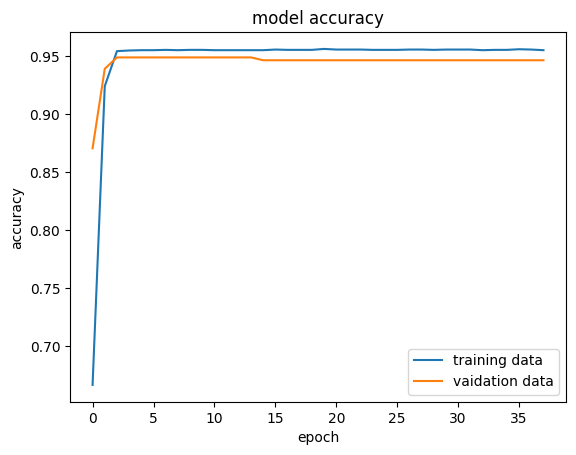

In [ ]:
plt.plot(demo.history['accuracy'])
plt.plot(demo.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['training data', 'vaidation data'], loc='lower right')

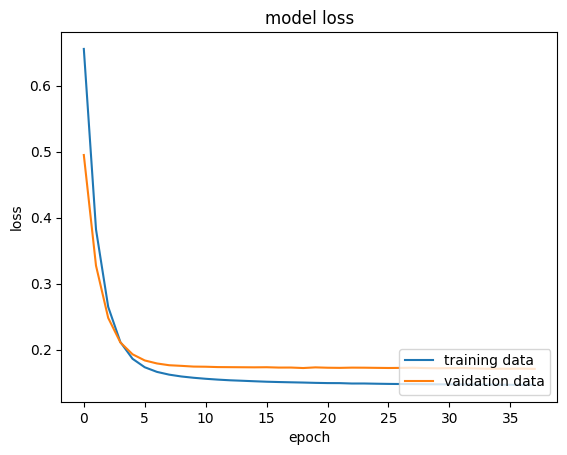

In [ ]:
plt.plot(demo.history['loss'])
plt.plot(demo.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['training data', 'vaidation data'], loc='lower right')